In [12]:
import xradar as xd
from io import BytesIO
from obstore.store import S3Store
import xarray as xr
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.cm as cm


In [2]:

# Start a local cluster with all CPU cores
cluster = LocalCluster()
client = Client(cluster)

# Check the dashboard
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 15.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:63569,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:63594,Total threads: 3
Dashboard: http://127.0.0.1:63601/status,Memory: 3.81 GiB
Nanny: tcp://127.0.0.1:63572,


In [3]:
bucket = "s3://s3-radaresideam"
store = S3Store.from_url(bucket, skip_signature=True)


In [4]:
async def list_raw_objects(path)-> list[str]:
    paths: list[str] = []
    async for batch in store.list(path):
        for obj in batch:
            paths.append(obj["path"])
    return paths

def get_geocoords(ds)-> xr.Dataset:
    """
    Converts Cartesian coordinates (x, y, z) in a radar dataset to geographic
    coordinates (longitude, latitude, altitude) using CRS transformation.

    Parameters
    ----------
    ds : xarray.Dataset
        Radar dataset with Cartesian coordinates.

    Returns
    -------
    xarray.Dataset
        Dataset with added 'lon', 'lat', and 'alt' coordinates and their attributes.
    """
    from pyproj import CRS, Transformer

    # Convert the dataset to georeferenced coordinates
    ds = ds.xradar.georeference()
    # Define source and target coordinate reference systems (CRS)
    src_crs = ds.xradar.get_crs()
    trg_crs = CRS.from_user_input(4326)  # EPSG:4326 (WGS 84)
    # Create a transformer for coordinate conversion
    transformer = Transformer.from_crs(src_crs, trg_crs)
    # Transform x, y, z coordinates to latitude, longitude, and altitude
    trg_y, trg_x, trg_z = transformer.transform(ds.x, ds.y, ds.z)
    # Assign new coordinates with appropriate attributes
    ds = ds.assign_coords(
        {
            "lon": (ds.x.dims, trg_x, xd.model.get_longitude_attrs()),
            "lat": (ds.y.dims, trg_y, xd.model.get_latitude_attrs()),
            "alt": (ds.z.dims, trg_z, xd.model.get_altitude_attrs()),
        }
    )
    return ds


In [5]:
paths = await list_raw_objects("l2_data/2025/04/02/Carimagua/")
paths[1553]

'l2_data/2025/04/02/Carimagua/CAR250402131004.RAW61VD'

In [6]:
result = store.get(paths[1553])

In [7]:
dt_car = xd.io.open_iris_datatree(BytesIO(result.bytes()),
        chunks={"azimuth": 360, "range": 497}
    ).xradar.map_over_sweeps(get_geocoords)

C:\Users\alfonso8\.conda\envs\raw2zarr-dev\Lib\site-packages\distributed\client.py:3357: UserWarning: Sending large graph of size 11.90 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


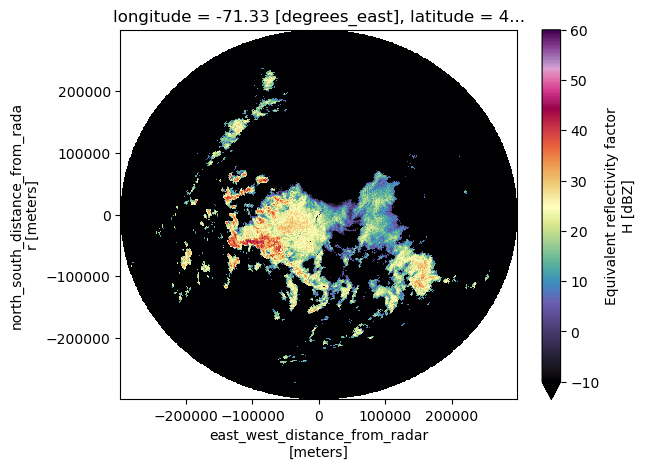

In [8]:
dt_car["sweep_0"].DBZH.plot(
    x="x",
    y="y",
    vmin=-10, 
    vmax=60,
    cmap="ChaseSpectral"
)

In [9]:
ds = dt_car["sweep_0"].ds
ds

<xarray.DatasetView> Size: 67MB
Dimensions:            (azimuth: 720, range: 994)
Coordinates: (12/14)
    elevation          (azimuth) float32 3kB dask.array<chunksize=(360,), meta=np.ndarray>
    time               (azimuth) datetime64[ns] 6kB dask.array<chunksize=(360,), meta=np.ndarray>
  * range              (range) float32 4kB 1e+03 1.3e+03 ... 2.986e+05 2.989e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
    ...                 ...
    x                  (azimuth, range) float64 6MB dask.array<chunksize=(360, 994), meta=np.ndarray>
    y                  (azimuth, range) float64 6MB dask.array<chunksize=(360, 994), meta=np.ndarray>
    z                  (azimuth, range) float64 6MB dask.array<chunksize=(360, 994), meta=np.ndarray>
    lon                (azimuth, range) float64 6MB -71.33 -71.33 ... -71.35
    lat                (azimuth, range) float64 6MB 4.573 4.575 ... 7.262 7.264
    alt                (azimuth, range) float64 6MB 214.5 217.1 ... 7.977e+03
Data variables: (12/17)
    DBTH               (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    DBZH               (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    VRADH              (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    WRADH              (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    ZDR                (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    KDP                (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    ...                 ...
    DB_DBZE8           (azimuth, range) float32 3MB dask.array<chunksize=(360, 497), meta=np.ndarray>
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...

C:\Users\alfonso8\AppData\Local\Temp\ipykernel_19624\1849384320.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("ChaseSpectral")(norm(dbz.values))


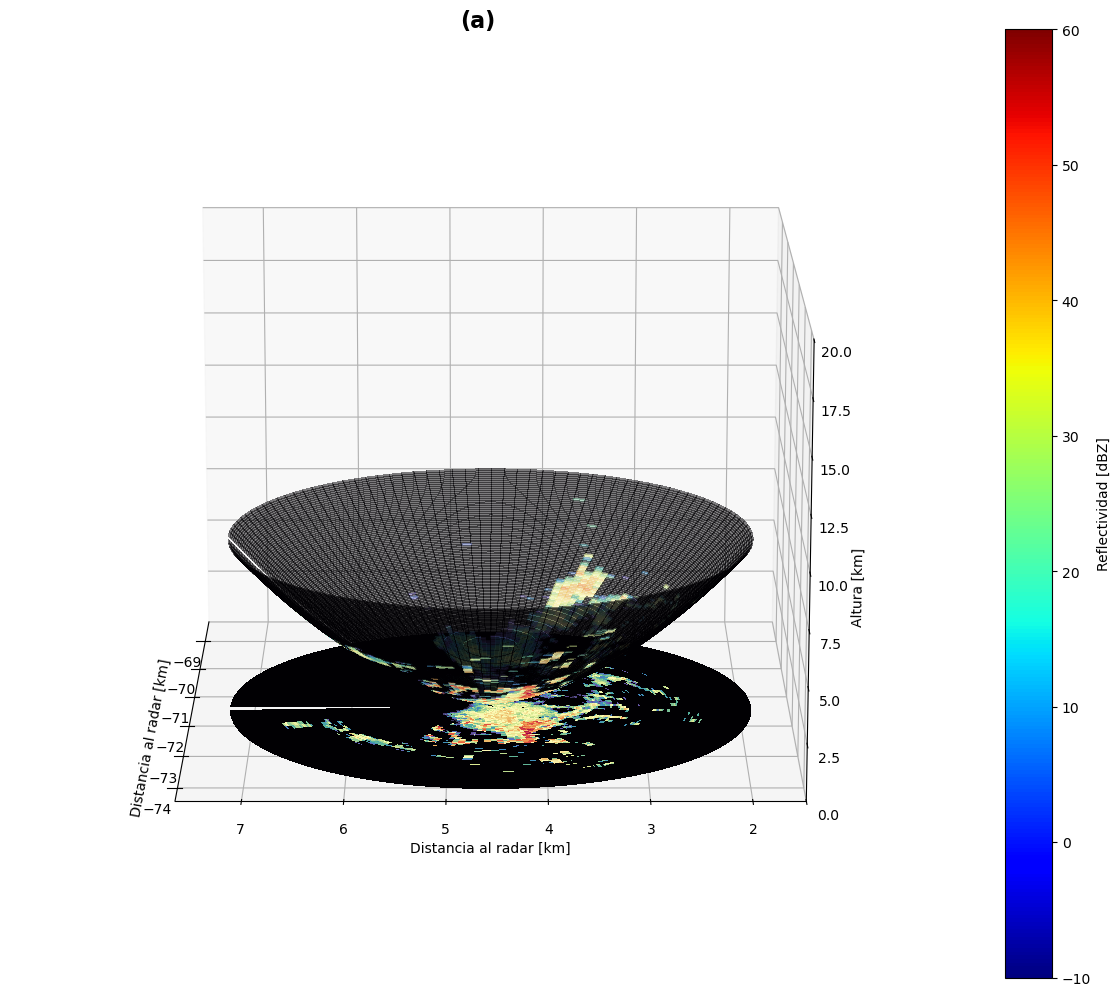

In [23]:
# Coarsen the data for faster plotting
step = 6# smaller step = higher resolution
x = ds.lon.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()
y = ds.lat.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()
z = ds.alt.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute() /1000
dbz = ds.DBZH.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

norm = plt.Normalize(vmin=-10, vmax=60)  # Tell it what dBZ means
colors = cm.get_cmap("ChaseSpectral")(norm(dbz.values))


# Plot the surface
surf = ax.plot_surface(
    x, y, z,
    facecolors=colors,
    rstride=1,
    cstride=1,
    linewidth=0,           # ✅ removes edge lines
    antialiased=False,     # ✅ avoids jagged edges
    shade=False,           # optional: disables lighting shadows
    alpha=0.5 
)

z = np.zeros_like(x)

ax.plot_surface(
    x, y, z,                     # Ground plane
    facecolors=colors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    edgecolor=None
)

# Hide axis ticks and add colorbar
m = plt.cm.ScalarMappable(cmap='jet', norm=norm)
m.set_array([])
fig.colorbar(m, ax=ax, label="Reflectividad [dBZ]")

ax.set_xlabel("Distancia al radar [km]")
ax.set_ylabel("Distancia al radar [km]")
ax.set_zlabel("Altura [km]")
ax.set_zlim(0, 20)
ax.view_init(elev=15, azim=180)

plt.title("(a)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


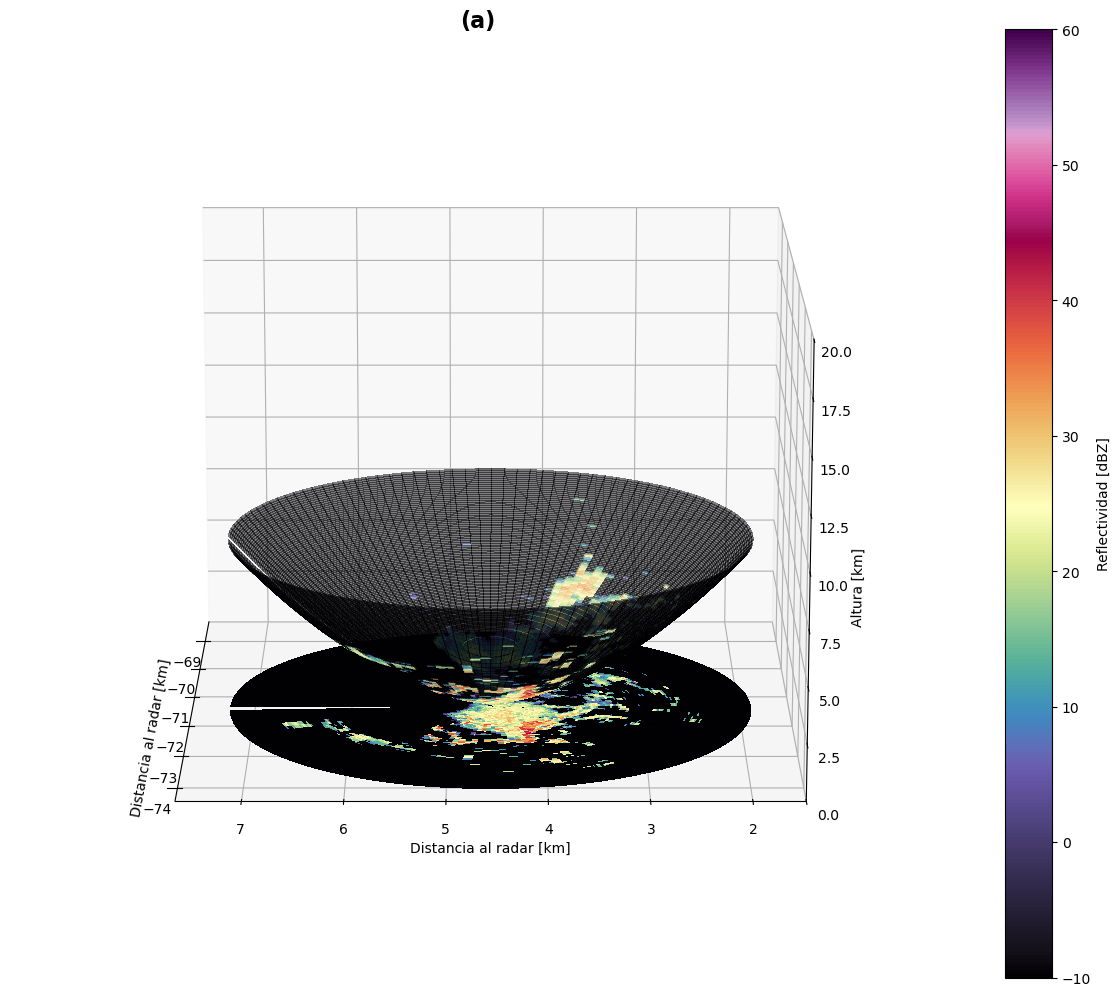

interactive(children=(IntSlider(value=15, description='elev', max=90, step=5), IntSlider(value=180, descriptio…

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact
import matplotlib.cm as cm
import xradar

# Register ChaseSpectral colormap

# Coarsen the data for faster plotting
step = 6
x = ds.lon.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()
y = ds.lat.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()
z = ds.alt.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute() / 1000  # km
dbz = ds.DBZH.isel(azimuth=slice(0, None, step), range=slice(0, None, step)).compute()

norm = plt.Normalize(vmin=-10, vmax=60)
colors = cm.get_cmap("ChaseSpectral")(norm(dbz.values))

@interact(elev=(0, 90, 5), azim=(0, 360, 15))
def plot_3d_radar(elev=15, azim=180):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Elevated reflectivity curtain
    ax.plot_surface(
        x, y, z,
        facecolors=colors,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=0.5,
        edgecolor='none'
    )

    # Ground plane reflectivity
    z0 = np.zeros_like(z)
    ax.plot_surface(
        x, y, z0,
        facecolors=colors,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=1.0,
        edgecolor='none'
    )

    # Colorbar
    mappable = cm.ScalarMappable(cmap='ChaseSpectral', norm=norm)
    mappable.set_array([])
    fig.colorbar(mappable, ax=ax, label="Reflectividad [dBZ]")

    ax.set_xlabel("Distancia al radar [km]")
    ax.set_ylabel("Distancia al radar [km]")
    ax.set_zlabel("Altura [km]")
    ax.set_zlim(0, 20)

    # Dynamic viewing angle
    ax.view_init(elev=elev, azim=azim)

    plt.title("(a)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
